##Bag of words

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, FastText

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [2]:
documents = [
    "I love playing cricket on weekends",
    "Football is the most popular sport in the world",
    "Machine learning is a branch of artificial intelligence",
    "Deep learning models need lots of data to train",
    "Pizza and pasta are my favorite Italian foods",
    "I enjoy cooking Indian food at home",
    "Natural language processing helps computers understand text",
    "Word embeddings capture the meaning of words"
]

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                          
    text = re.sub(r'[^a-z\s]', '', text)         
    tokens = text.split()                        
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return tokens

tokenized_docs = [preprocess(doc) for doc in documents]
cleaned_docs = [" ".join(tokens) for tokens in tokenized_docs]

for original, cleaned in zip(documents, cleaned_docs):
    print(f"Before: {original}")
    print(f"After : {cleaned}")
    print("-" * 50)

In [4]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(cleaned_docs)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Shape of BoW matrix:", bow_matrix.shape)
bow_df

Shape of BoW matrix: (8, 41)


,artificial,branch,capture,computers,cooking,cricket,data,deep,embeddings,enjoy,...,popular,processing,sport,text,train,understand,weekends,word,words,world
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,1
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,1,0,0,0,0
7,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,0


##TF-IDF

In [5]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_docs)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)
tfidf_df.round(3)

Shape of TF-IDF matrix: (8, 41)


,artificial,branch,capture,computers,cooking,cricket,data,deep,embeddings,enjoy,...,popular,processing,sport,text,train,understand,weekends,word,words,world
0,0.000,0.000,0.000,0.000,0.000,0.5,0.000,0.000,0.000,0.000,...,0.0,0.000,0.0,0.000,0.000,0.000,0.5,0.000,0.000,0.0
1,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,...,0.5,0.000,0.5,0.000,0.000,0.000,0.0,0.000,0.000,0.5
2,0.461,0.461,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,...,0.0,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.0
3,0.000,0.000,0.000,0.000,0.000,0.0,0.386,0.386,0.000,0.000,...,0.0,0.000,0.0,0.000,0.386,0.000,0.0,0.000,0.000,0.0
4,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,...,0.0,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.0
5,0.000,0.000,0.000,0.000,0.447,0.0,0.000,0.000,0.000,0.447,...,0.0,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.0
6,0.000,0.000,0.000,0.378,0.000,0.0,0.000,0.000,0.000,0.000,...,0.0,0.378,0.0,0.378,0.000,0.378,0.0,0.000,0.000,0.0
7,0.000,0.000,0.447,0.000,0.000,0.0,0.000,0.000,0.447,0.000,...,0.0,0.000,0.0,0.000,0.000,0.000,0.0,0.447,0.447,0.0


In [6]:
for i, row in enumerate(tfidf_df.values):
    top_idx = row.argsort()[-3:][::-1]
    top_words = [(tfidf_df.columns[j], round(row[j], 3)) for j in top_idx]
    print(f"Doc {i}: {documents[i]}")
    print(f"  Top words: {top_words}")
    print()

Doc 0: I love playing cricket on weekends
  Top words: [('weekends', 0.5), ('love', 0.5), ('cricket', 0.5)]

Doc 1: Football is the most popular sport in the world
  Top words: [('world', 0.5), ('sport', 0.5), ('popular', 0.5)]

Doc 2: Machine learning is a branch of artificial intelligence
  Top words: [('intelligence', 0.461), ('artificial', 0.461), ('branch', 0.461)]

Doc 3: Deep learning models need lots of data to train
  Top words: [('train', 0.386), ('data', 0.386), ('lots', 0.386)]

Doc 4: Pizza and pasta are my favorite Italian foods
  Top words: [('pasta', 0.447), ('foods', 0.447), ('italian', 0.447)]

Doc 5: I enjoy cooking Indian food at home
  Top words: [('indian', 0.447), ('home', 0.447), ('food', 0.447)]

Doc 6: Natural language processing helps computers understand text
  Top words: [('understand', 0.378), ('processing', 0.378), ('text', 0.378)]

Doc 7: Word embeddings capture the meaning of words
  Top words: [('words', 0.447), ('word', 0.447), ('capture', 0.447)]



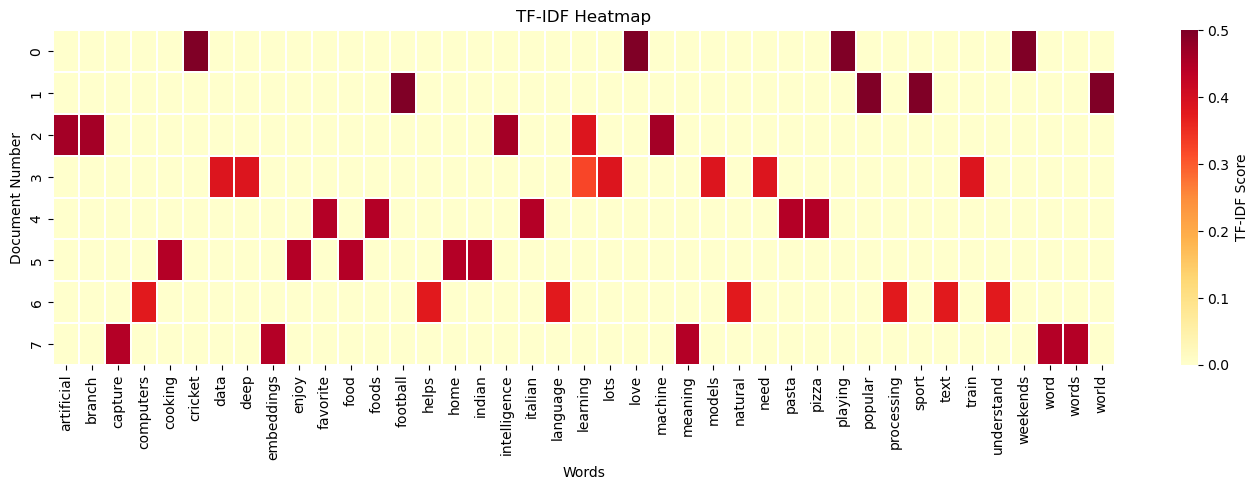

In [7]:
plt.figure(figsize=(14, 5))
sns.heatmap(tfidf_df, cmap='YlOrRd', cbar_kws={'label': 'TF-IDF Score'}, linewidths=0.3)
plt.title('TF-IDF Heatmap')
plt.xlabel('Words')
plt.ylabel('Document Number')
plt.tight_layout()
plt.show()

Word2Vec

In [8]:
w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=50,    # each word becomes a 50-number vector
    window=3,          # look at 3 words before and after
    min_count=1,       # include even words that appear once
    sg=1,              # 1 = skip-gram, 0 = CBOW
    workers=2,
    epochs=100         # more rounds of learning since dataset is small
)

print("Vocabulary size:", len(w2v_model.wv.index_to_key))
print("\nVector for 'learning' (first 10 numbers):")
print(w2v_model.wv['learning'][:10])

Vocabulary size: 41

Vector for 'learning' (first 10 numbers):
[-0.00112922  0.00043351  0.01038801  0.0177319  -0.01890318 -0.01472016
  0.01323622  0.0184438  -0.01035537 -0.00788412]


In [9]:
for word in ['cricket', 'learning', 'food']:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        print(f"Words similar to '{word}': {similar}")

Words similar to 'cricket': [('food', 0.4345901906490326), ('language', 0.29238176345825195), ('favorite', 0.1843152940273285)]
Words similar to 'learning': [('foods', 0.2772181034088135), ('machine', 0.2548319101333618), ('food', 0.228847473859787)]
Words similar to 'food': [('language', 0.5467944741249084), ('cricket', 0.4345901608467102), ('train', 0.4116916358470917)]


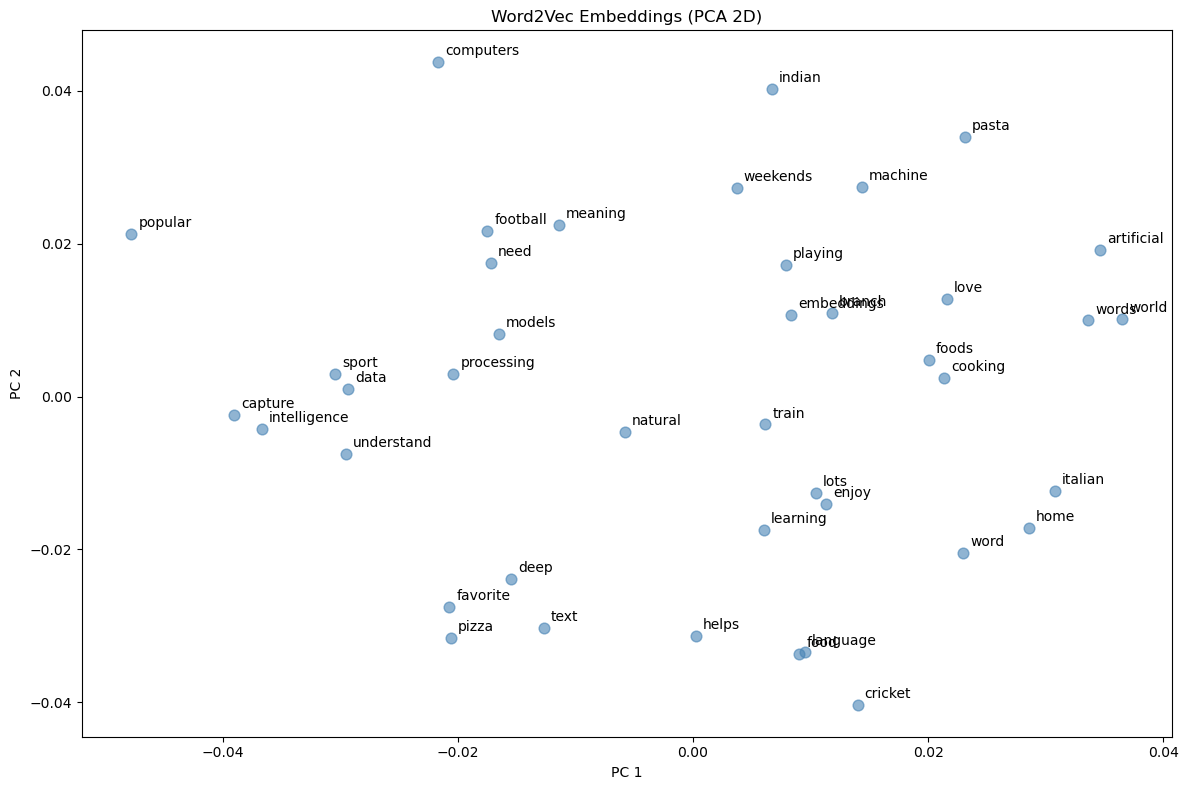

In [10]:
words = list(w2v_model.wv.index_to_key)
vectors = np.array([w2v_model.wv[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=60, c='steelblue', alpha=0.6)
for i, word in enumerate(words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=10, xytext=(5, 5), textcoords='offset points')
plt.title('Word2Vec Embeddings (PCA 2D)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

In [12]:
ft_model = FastText(
    sentences=tokenized_docs,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    workers=2,
    epochs=100,
    min_n=3,    # smallest piece size
    max_n=6     # largest piece size
)

print("Vocabulary size:", len(ft_model.wv.index_to_key))

Vocabulary size: 41


In [13]:
unknown_words = ['cricketer', 'learnings', 'pizzas']

for w in unknown_words:
    in_vocab = w in ft_model.wv.key_to_index
    vec = ft_model.wv[w]
    print(f"'{w}' — was in training data: {in_vocab}, but vector still works! Shape: {vec.shape}")

'cricketer' — was in training data: False, but vector still works! Shape: (50,)
'learnings' — was in training data: False, but vector still works! Shape: (50,)
'pizzas' — was in training data: False, but vector still works! Shape: (50,)


In [14]:
for word in ['cricket', 'learning', 'food']:
    if word in ft_model.wv:
        similar = ft_model.wv.most_similar(word, topn=3)
        print(f"Words similar to '{word}': {similar}")

Words similar to 'cricket': [('branch', 0.2752930521965027), ('learning', 0.24993135035037994), ('meaning', 0.24434426426887512)]
Words similar to 'learning': [('cooking', 0.37155425548553467), ('embeddings', 0.34968265891075134), ('sport', 0.3311169147491455)]
Words similar to 'food': [('foods', 0.5608298778533936), ('home', 0.40393882989883423), ('learning', 0.2567531168460846)]


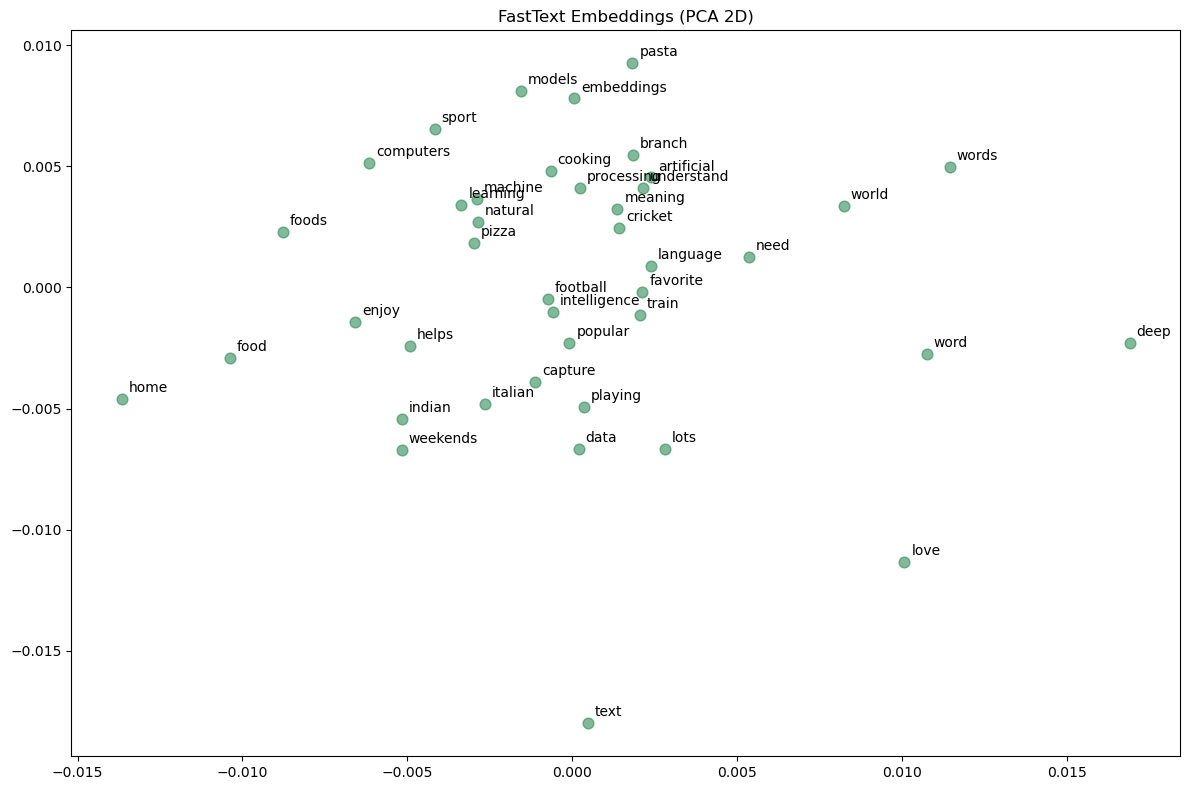

In [15]:
words = list(ft_model.wv.index_to_key)
vectors = np.array([ft_model.wv[w] for w in words])

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=60, c='seagreen', alpha=0.6)
for i, word in enumerate(words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=10, xytext=(5, 5), textcoords='offset points')
plt.title('FastText Embeddings (PCA 2D)')
plt.tight_layout()
plt.show()